EDA
1.Import csv and initial analysis

In [ ]:
import pandas as pd
df1 = pd.read_csv("customer_churn_dataset-testing.csv")
print(df1.head())

   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                18      0  
4                18      0  


In [ ]:
df2 = pd.read_csv("customer_churn_dataset-training.csv")
print(df2.head())

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

In [3]:
df = pd.concat([df1, df2], axis=0, ignore_index=True)

In [4]:
df.shape

(505207, 12)

2. Drop null values

In [6]:
df.dropna(inplace=True)

In [7]:
df.shape

(505206, 12)

In [8]:
print(df[df.isnull().any(axis=1)])

Empty DataFrame
Columns: [CustomerID, Age, Gender, Tenure, Usage Frequency, Support Calls, Payment Delay, Subscription Type, Contract Length, Total Spend, Last Interaction, Churn]
Index: []


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505206 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 50.1+ MB


In [10]:
# Count unique values in each column
unique_counts = df.nunique().sort_values(ascending=True)

print("Unique values per column:\n", unique_counts)

Unique values per column:
 Gender                    2
Churn                     2
Contract Length           3
Subscription Type         3
Support Calls            11
Last Interaction         30
Usage Frequency          30
Payment Delay            31
Age                      48
Tenure                   60
Total Spend           68363
CustomerID           442211
dtype: int64


3. Drop CustomerID 

In [11]:
df = df.drop(columns=['CustomerID'], axis=1)

In [ ]:
df.describe().round(2)

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.00,505206.00,505206.00,505206.00,505206.00,505206.00,505206.00,505206.00
mean,39.70,31.35,15.71,3.83,13.50,620.07,14.61,0.56
std,12.67,17.24,8.62,3.13,8.45,245.32,8.61,0.50
min,18.00,1.00,1.00,0.00,0.00,100.00,1.00,0.00
25%,29.00,16.00,8.00,1.00,6.00,446.00,7.00,0.00
50%,40.00,32.00,16.00,3.00,13.00,649.00,14.00,1.00
75%,49.00,46.00,23.00,6.00,20.00,824.00,22.00,1.00
max,65.00,60.00,30.00,10.00,30.00,1000.00,30.00,1.00


In [ ]:
float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].round().astype('int64')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505206 entries, 0 to 505206
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Age                505206 non-null  int64 
 1   Gender             505206 non-null  object
 2   Tenure             505206 non-null  int64 
 3   Usage Frequency    505206 non-null  int64 
 4   Support Calls      505206 non-null  int64 
 5   Payment Delay      505206 non-null  int64 
 6   Subscription Type  505206 non-null  object
 7   Contract Length    505206 non-null  object
 8   Total Spend        505206 non-null  int64 
 9   Last Interaction   505206 non-null  int64 
 10  Churn              505206 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 46.3+ MB


4. Univariate Analysis

4.1 Categorical Features

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

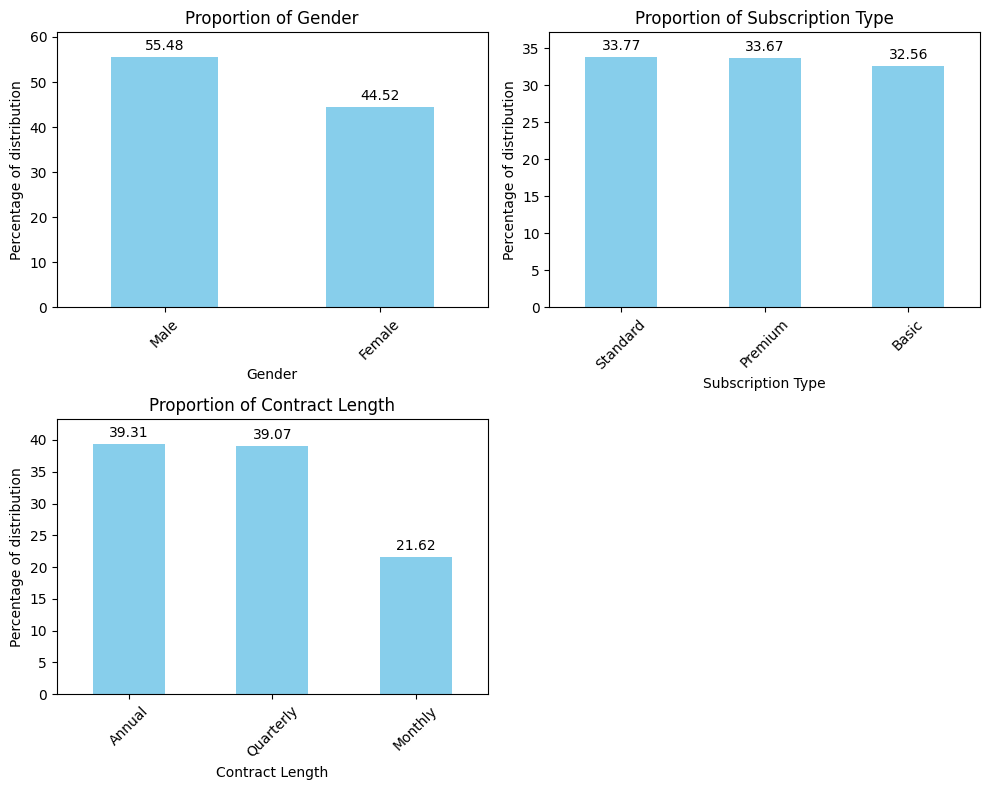

In [ ]:
cat_columns=['Gender','Subscription Type','Contract Length']

n_cols = 2
n_rows = (len(cat_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(2, 2, figsize=(10, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(cat_columns):
    bars = df[col].value_counts(normalize=True).mul(100).round(2).plot(kind='bar',ax=axes[i],color='skyblue')
    axes[i].set_title(f"Proportion of {col}")
    axes[i].set_ylabel("Percentage of distribution")
    axes[i].bar_label(bars.containers[0], padding=3)
    axes[i].set_ylim(0, df[col].value_counts(normalize=True).mul(100).max() * 1.1) # to show the bar values clearly,ax.set_ylim lets you control the y‑axis range,Multiplying the max value by 1.1 (or 1.2) gives extra headroom for labels.

    axes[i].tick_params(axis='x', rotation=45)


fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


4.2 Numerical features

In [17]:
n_cols = df.select_dtypes(include=['int64','float64']).drop(columns='Churn')
numbers_cols = n_cols.columns.to_list()
numbers_cols

['Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction']

In [ ]:

exclude_cols = ['Total Spend']

num_cols = [col for col in numbers_cols if col not in exclude_cols]

print(num_cols)


['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Last Interaction']


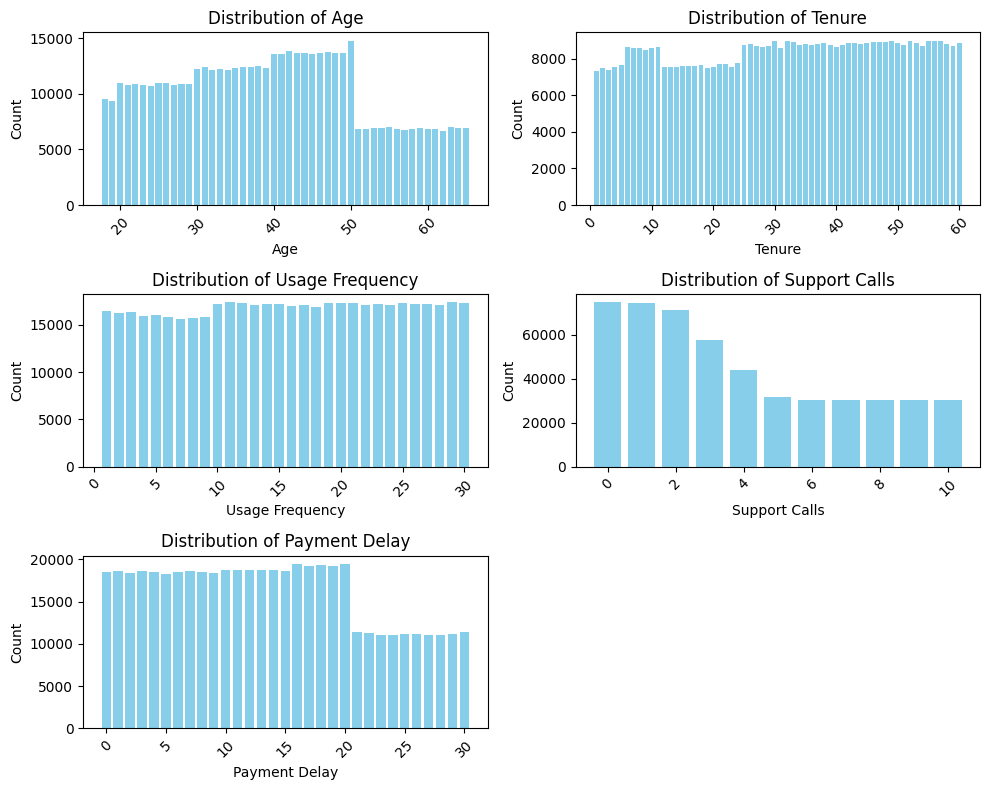

In [19]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10,8))
axes = axes.flatten()

# Plot count distribution for each numeric column
for i, col in enumerate(num_cols):
    value_counts = df[col].value_counts().sort_index()
    axes[i].bar(value_counts.index, value_counts.values, color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)


# Hide unused subplots if fewer than 8 columns
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


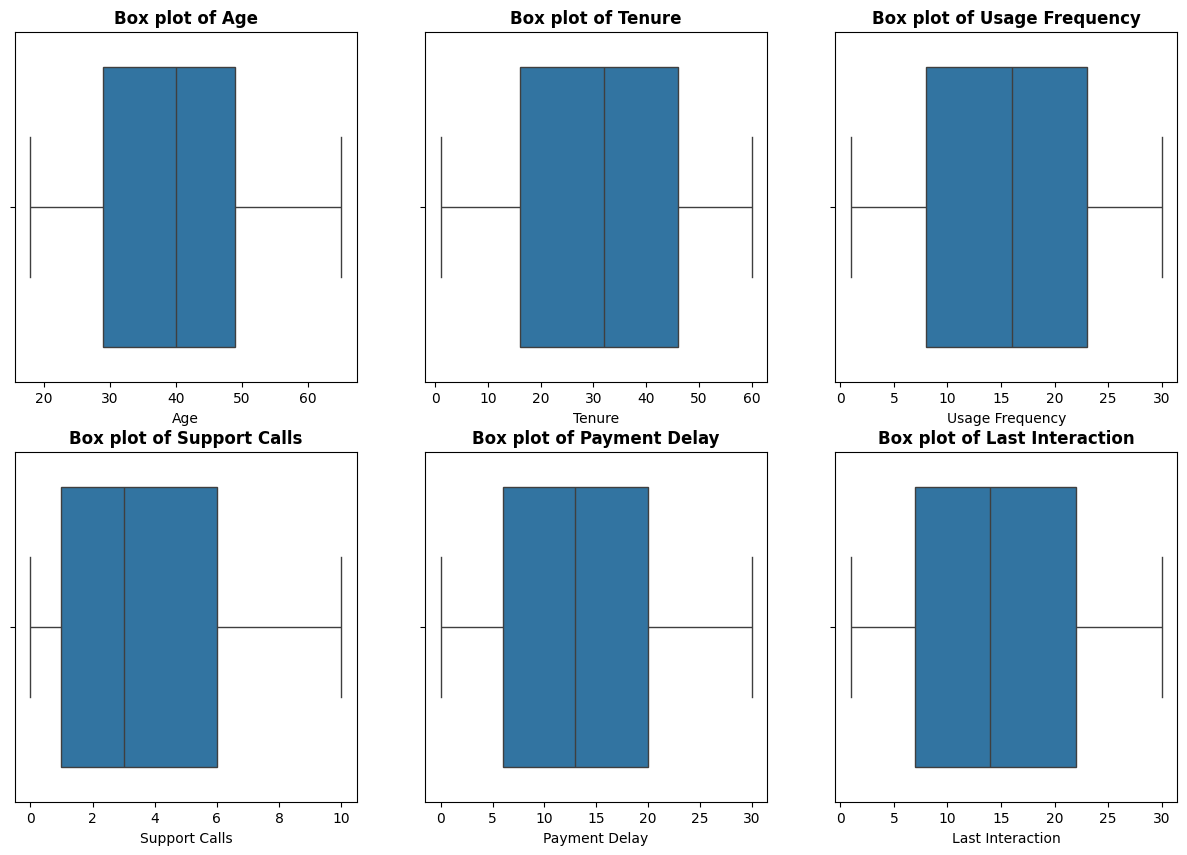

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten() 

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Box plot of {col}', fontweight='bold')


4.3 Continuous Analysis

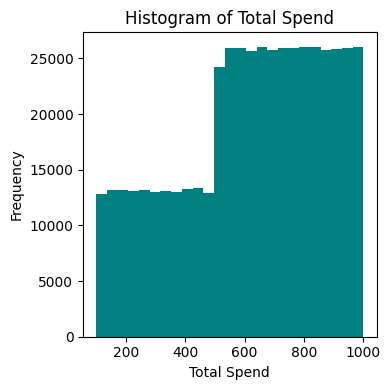

In [ ]:
plt.figure(figsize=(4,4))
plt.hist(df['Total Spend'], bins=25, color='teal')
plt.title('Histogram of Total Spend')
plt.xlabel('Total Spend')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


5. Class Imbalances

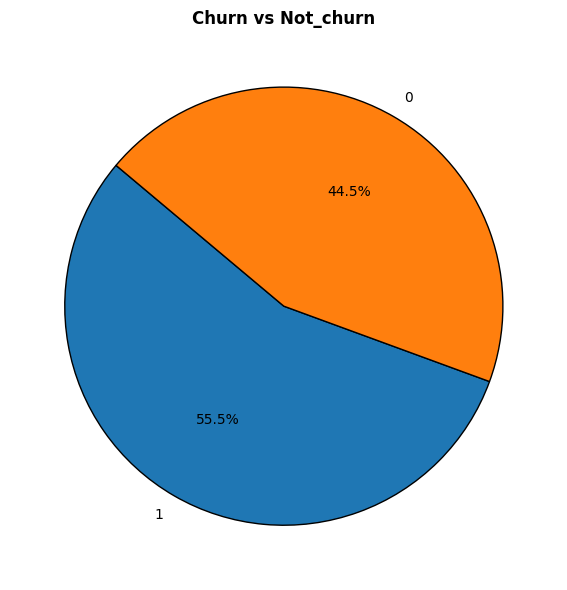

In [22]:
target_counts = df['Churn'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Churn vs Not_churn', fontweight='bold')
plt.tight_layout()
plt.show()


6. Bivariate analysis

In [23]:
def multivariate(col):
    # Group by gender and churn
    grouped = df.groupby([col, 'Churn']).size().unstack(fill_value=0)

    # Plot
    grouped.plot(kind='bar', figsize=(8, 6), color=['salmon', 'skyblue'], edgecolor='black')

    plt.title(f"Churn vs Non-Churn by {col}", fontweight='bold')
    plt.xlabel(f"{col}")
    plt.ylabel('Count')
    plt.legend(['Not Churned', 'Churned'], title='Churn Status')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

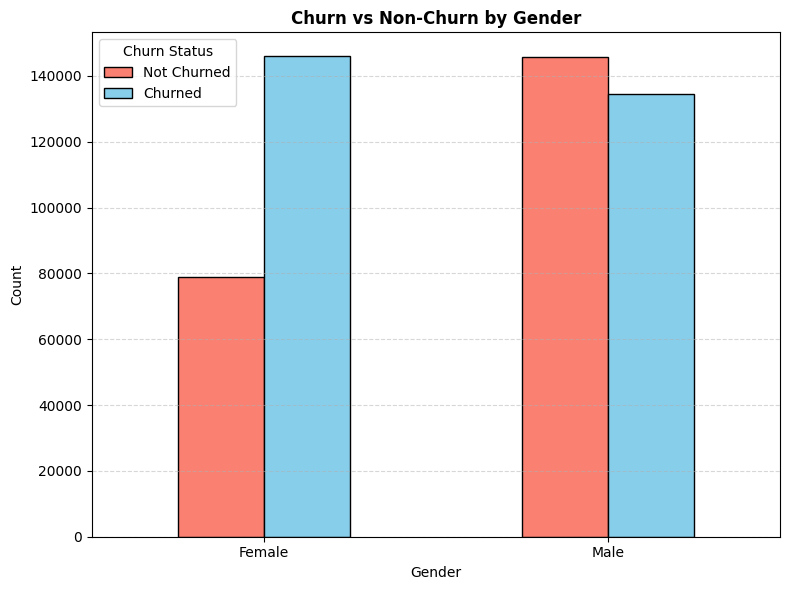

In [24]:
multivariate('Gender')

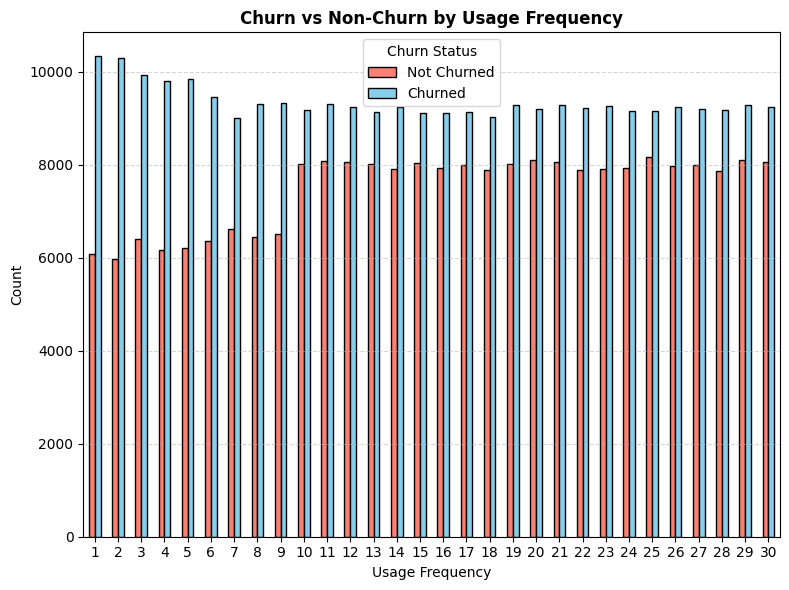

In [25]:
multivariate('Usage Frequency')

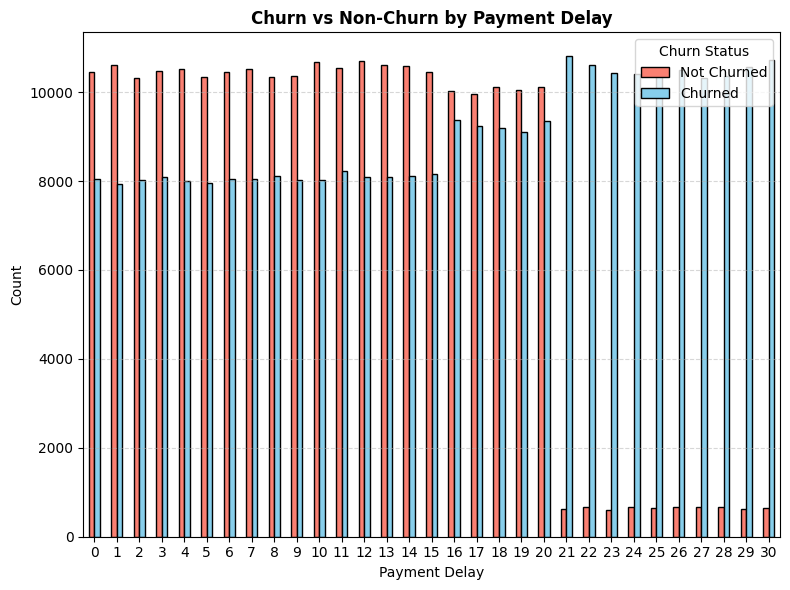

In [26]:
multivariate('Payment Delay')

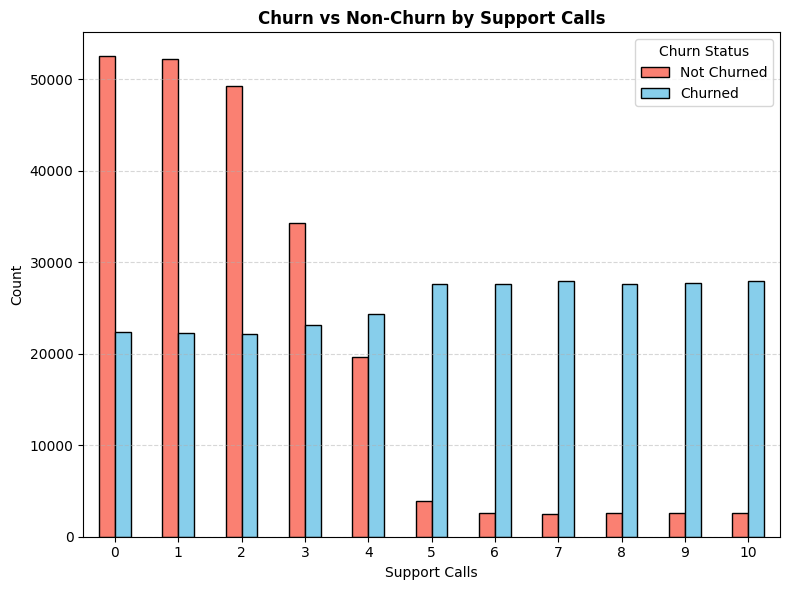

In [27]:
multivariate('Support Calls')

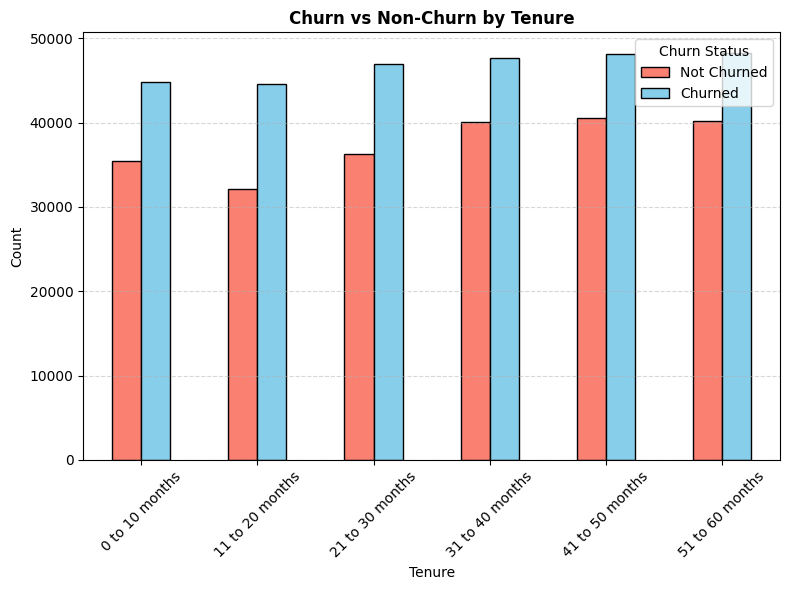

In [ ]:
def categorize_age(age):
    if 0 <= age <= 10:
        return '0 to 10 months'
    elif 11 <= age <= 20:
        return '11 to 20 months'
    elif 21 <= age <= 30:
        return '21 to 30 months'
    elif 31 <= age <= 40:
        return '31 to 40 months'
    elif 41 <= age <= 50:
        return '41 to 50 months'
    elif 51 <= age <= 60:
        return '51 to 60 months'
    else:
        pass # For nan values

filtered = df.copy()
filtered['tenure_segmentation'] = df['Tenure'].apply(categorize_age)

filtered = filtered.groupby(['tenure_segmentation', 'Churn']).size().unstack()

filtered.plot(kind='bar', figsize=(8, 6), color=['salmon', 'skyblue'], edgecolor='black')

plt.title("Churn vs Non-Churn by Tenure", fontweight='bold')
plt.xlabel("Tenure")
plt.ylabel('Count')
plt.legend(['Not Churned', 'Churned'], title='Churn Status')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [29]:
def multivariate(col):
    # Group by column and churn
    grouped = df.groupby([col, 'Churn']).size().unstack(fill_value=0)

    # Plot
    ax = grouped.plot(kind='bar', figsize=(8, 6), color=['salmon', 'skyblue'], edgecolor='black')

    # Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, label_type='edge', fontsize=10, padding=3)

    # Styling
    plt.title(f"Churn vs Non-Churn by {col}", fontweight='bold')
    plt.xlabel(f"{col}")
    plt.ylabel('Count')
    plt.legend(['Not Churned', 'Churned'], title='Churn Status',loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


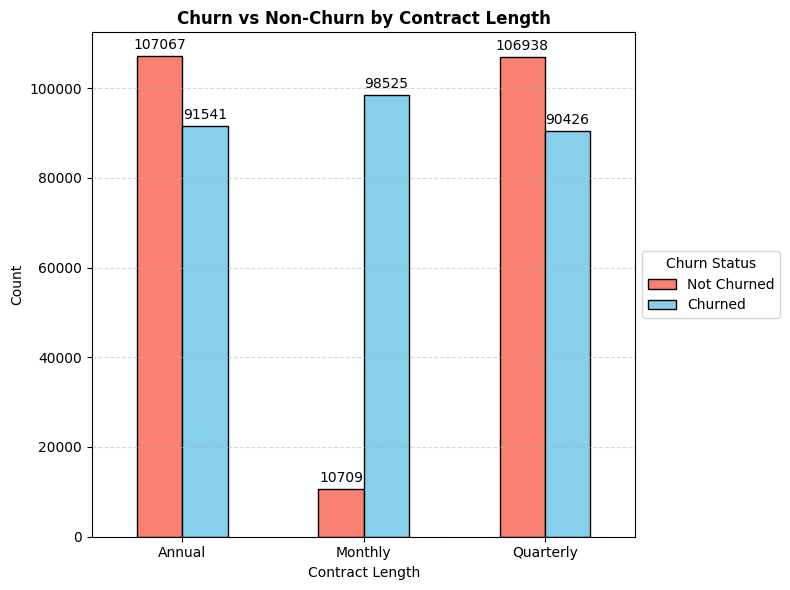

In [30]:
multivariate('Contract Length')

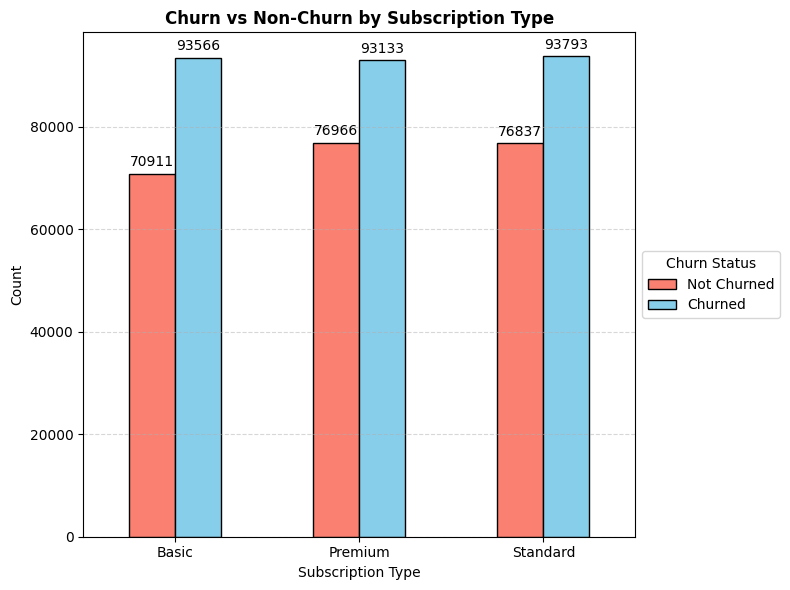

In [31]:
multivariate('Subscription Type')

Correlation

In [37]:
final_df = df.copy()
cat_columns=['Gender','Subscription Type','Contract Length']
final_df = final_df.drop(columns= cat_columns, axis=1)

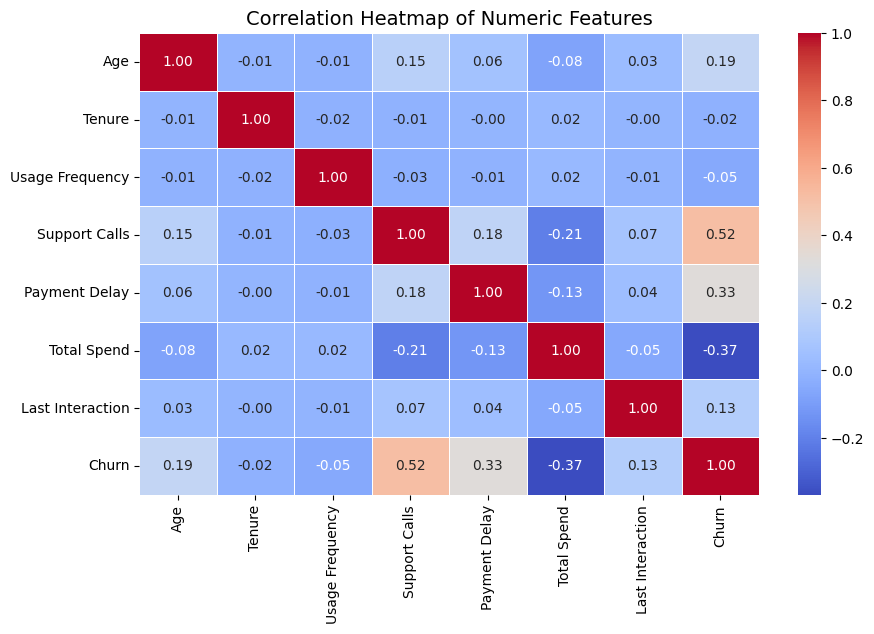

In [38]:
co1=final_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(co1, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.show()

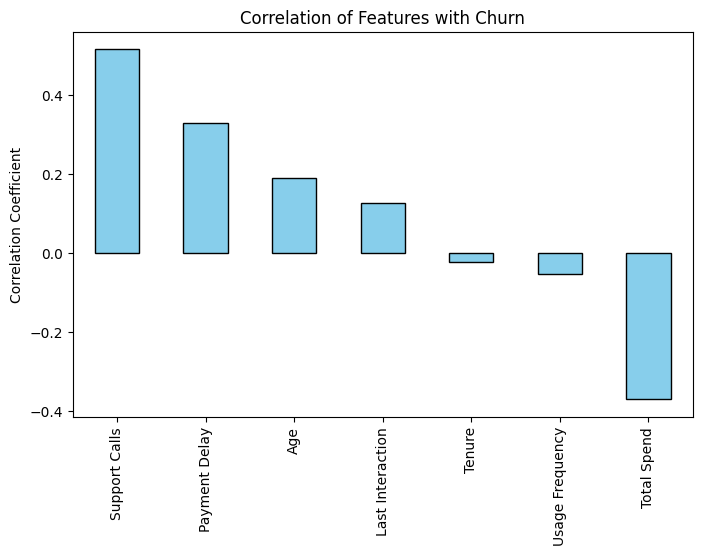

In [39]:
corr_with_churn = co1["Churn"].drop("Churn").sort_values(ascending=False)

plt.figure(figsize=(8,5))
corr_with_churn.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Correlation of Features with Churn")
plt.ylabel("Correlation Coefficient")
plt.show()